<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/python/libraries/web_scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install requests
!pip install BeautifulSoup4

In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [5]:
def scraping_quotes(number_of_pages,path=None): #This is the main controller function.Calls the scraping logic,Converts data into CSV,Saves output to a file
    """Get the quotes and write them into a csv file"""
    if path is None:
        path='Quotes.csv'
    items=parse_quotes(number_of_pages)
    df=pd.DataFrame(items)
    df.to_csv(path,index=None)
    print('Quotes information for {} pages written to file "{}"'.format(number_of_pages,path))
    return path

In [6]:
def parse_quotes(number_of_pages):
    """Get the list of dictionaries having quotes, author names and other information for the particular number of pages """
    subject_names,urls,author_names,quotes_list=[],[],[],[]
    for i in range(1,number_of_pages+1):
        page=str(i)
        quote_doc=get_webpage(page)
        div_tags=quote_doc.find_all('div',class_='quote')
        subject_names.extend(get_quote_tag(div_tags))  #joining the lists so that only elements are added to get a single list pages'
        urls.extend(get_author_urls(div_tags))         #joining the lists so that only elements are added to get a single list
        author_names.extend(get_author_name(div_tags)) #joining the lists so that only elements are added to get a single list
        quotes_list.extend(get_quotes(div_tags))       #joining the lists so that only elements are added to get a single list
        Quotes_list=list_of_dict(quotes_list,author_names,urls,subject_names)
    return Quotes_list

In [7]:
def get_quotes(div_tags):
    """Get the list of quotes for one page"""
    quotes=[]
    for tag in div_tags:
        quote=tag.find('span',class_='text').text
        quotes.append(quote)
    return quotes

In [8]:
def get_author_urls(div_tags):
    """ Get the list of urls for one page"""
    author_links=[]
    for tag in div_tags:
        span_tag=tag.find('span',class_=None)
        author_link='http://quotes.toscrape.com'+span_tag.find('a')['href']
        author_links.append(author_link)
    return author_links

In [9]:
def get_quote_tag(div_tags):
    """Get the quote tags for different quotes for one page"""
    name_tags=[]
    for tag in div_tags:
        name_tag=tag.find('div',class_='tags').meta['content']
        name_tags.append(name_tag)
    return name_tags

In [10]:
def get_author_name(div_tags):
    """Get the author names for the quotes for one page"""
    authors=[]
    for tag in div_tags:
        span_tag=tag.find('span',class_=None)
    #print(span_tag)
        author=span_tag.find('small',class_='author').text
        authors.append(author)
    return authors

In [11]:
def list_of_dict(quotes_list,author_names,urls,subject_names):
    """Convert the lists into one list of dictionaries having quote, author names, link, tags"""
    return [{'Quotes': quotes_list[i],
             'Author': author_names[i],
             'Tags': subject_names[i],
             'Link': urls[i]} for i in range(len(quotes_list))]

In [12]:
def get_webpage(page):
    """Get the webpage containing quotes, authors etc."""
    #construct the url
    url='http://quotes.toscrape.com/page/'+page+'/'

    #using request download the webpage
    response=requests.get(url)

    #check if the process is successful
    if response.status_code!=200:
        print('Status Code:',response.status_code)
        raise Exception ('We Failed to fetch the webpage')+url
    else:
        doc=BeautifulSoup(response.text,'html.parser')
    return doc

In [13]:
scraping_quotes(10)

Quotes information for 10 pages written to file "Quotes.csv"


'Quotes.csv'

In [20]:
pd.read_csv('Quotes.csv')

,Quotes,Author,Tags,Link
0,“The world as we have created it is a process ...,Albert Einstein,"change,deep-thoughts,thinking,world",http://quotes.toscrape.com/author/Albert-Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities,choices",http://quotes.toscrape.com/author/J-K-Rowling
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational,life,live,miracle,miracles",http://quotes.toscrape.com/author/Albert-Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy,books,classic,humor",http://quotes.toscrape.com/author/Jane-Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself,inspirational",http://quotes.toscrape.com/author/Marilyn-Monroe
...,...,...,...,...
95,“You never really understand a person until yo...,Harper Lee,better-life-empathy,http://quotes.toscrape.com/author/Harper-Lee
96,“You have to write the book that wants to be w...,Madeleine L'Engle,"books,children,difficult,grown-ups,write,write...",http://quotes.toscrape.com/author/Madeleine-LE...
97,“Never tell the truth to people who are not wo...,Mark Twain,truth,http://quotes.toscrape.com/author/Mark-Twain
98,"“A person's a person, no matter how small.”",Dr. Seuss,inspirational,http://quotes.toscrape.com/author/Dr-Seuss


In [17]:
# Load scraped data
df = pd.read_csv('/content/Quotes.csv')

In [18]:
# View first 5 rows
print(df.head())

                                              Quotes           Author  \
0  “The world as we have created it is a process ...  Albert Einstein   
1  “It is our choices, Harry, that show what we t...     J.K. Rowling   
2  “There are only two ways to live your life. On...  Albert Einstein   
3  “The person, be it gentleman or lady, who has ...      Jane Austen   
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe   

                                       Tags  \
0       change,deep-thoughts,thinking,world   
1                         abilities,choices   
2  inspirational,life,live,miracle,miracles   
3             aliteracy,books,classic,humor   
4                 be-yourself,inspirational   

                                                Link  
0  http://quotes.toscrape.com/author/Albert-Einstein  
1      http://quotes.toscrape.com/author/J-K-Rowling  
2  http://quotes.toscrape.com/author/Albert-Einstein  
3      http://quotes.toscrape.com/author/Jane-Austen  
4  

In [19]:
# Shape of data
print("Rows, Columns:", df.shape)

# Column names
print(df.columns)

# Data types
print(df.dtypes)

# Summary info
df.info()

Rows, Columns: (100, 4)
Index(['Quotes', 'Author', 'Tags', 'Link'], dtype='object')
Quotes    object
Author    object
Tags      object
Link      object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Quotes  100 non-null    object
 1   Author  100 non-null    object
 2   Tags    97 non-null     object
 3   Link    100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


In [22]:
#null value check
df.isnull().sum()

,0
Quotes,0
Author,0
Tags,3
Link,0


In [23]:
# remove duplicate quotes
df = df.drop_duplicates(subset="Quotes")
print("After removing duplicates:", df.shape)

After removing duplicates: (100, 4)


In [26]:
unique_authors = df["Author"].nunique()            # .nunique for categorial values and .unique for numeric values

print("Number of unique authors:", unique_authors)

Number of unique authors: 50


In [27]:
einstein_quotes = df[df["Author"] == "Albert Einstein"]
print(einstein_quotes[["Quotes", "Tags"]])

                                               Quotes  \
0   “The world as we have created it is a process ...   
2   “There are only two ways to live your life. On...   
5   “Try not to become a man of success. Rather be...   
12  “If you can't explain it to a six year old, yo...   
26  “If you want your children to be intelligent, ...   
28  “Logic will get you from A to Z; imagination w...   
37   “Any fool can know. The point is to understand.”   
44  “Life is like riding a bicycle. To keep your b...   
53  “If I were not a physicist, I would probably b...   
80  “Anyone who has never made a mistake has never...   

                                        Tags  
0        change,deep-thoughts,thinking,world  
2   inspirational,life,live,miracle,miracles  
5                    adulthood,success,value  
12                     simplicity,understand  
26                      children,fairy-tales  
28                               imagination  
37   knowledge,learning,understanding,wisdo

In [28]:
author_counts = df["Author"].value_counts()
print(author_counts.head(10))

Author
Albert Einstein      10
J.K. Rowling          9
Marilyn Monroe        7
Dr. Seuss             6
Mark Twain            6
Jane Austen           5
C.S. Lewis            5
Bob Marley            3
Mother Teresa         2
Eleanor Roosevelt     2
Name: count, dtype: int64


In [29]:
df["Tag_List"] = df["Tags"].str.split(",")
print(df[["Tags", "Tag_List"]].head())

                                       Tags  \
0       change,deep-thoughts,thinking,world   
1                         abilities,choices   
2  inspirational,life,live,miracle,miracles   
3             aliteracy,books,classic,humor   
4                 be-yourself,inspirational   

                                         Tag_List  
0        [change, deep-thoughts, thinking, world]  
1                            [abilities, choices]  
2  [inspirational, life, live, miracle, miracles]  
3              [aliteracy, books, classic, humor]  
4                    [be-yourself, inspirational]  


In [30]:
tags_df = df.explode("Tag_List")
tags_df["Tag_List"] = tags_df["Tag_List"].str.strip()
print(tags_df.head())

                                              Quotes           Author  \
0  “The world as we have created it is a process ...  Albert Einstein   
0  “The world as we have created it is a process ...  Albert Einstein   
0  “The world as we have created it is a process ...  Albert Einstein   
0  “The world as we have created it is a process ...  Albert Einstein   
1  “It is our choices, Harry, that show what we t...     J.K. Rowling   

                                  Tags  \
0  change,deep-thoughts,thinking,world   
0  change,deep-thoughts,thinking,world   
0  change,deep-thoughts,thinking,world   
0  change,deep-thoughts,thinking,world   
1                    abilities,choices   

                                                Link       Tag_List  
0  http://quotes.toscrape.com/author/Albert-Einstein         change  
0  http://quotes.toscrape.com/author/Albert-Einstein  deep-thoughts  
0  http://quotes.toscrape.com/author/Albert-Einstein       thinking  
0  http://quotes.toscrape.co

In [31]:
top_tags = tags_df["Tag_List"].value_counts()
print(top_tags.head(10))

Tag_List
love             14
inspirational    13
life             13
humor            12
books            11
reading           7
friendship        5
friends           4
truth             4
death             3
Name: count, dtype: int64


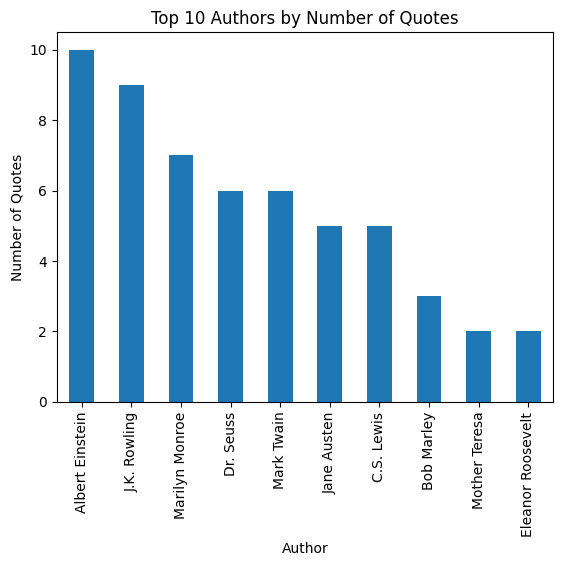

In [32]:
import matplotlib.pyplot as plt

author_counts.head(10).plot(kind="bar")
plt.title("Top 10 Authors by Number of Quotes")
plt.xlabel("Author")
plt.ylabel("Number of Quotes")
plt.show()

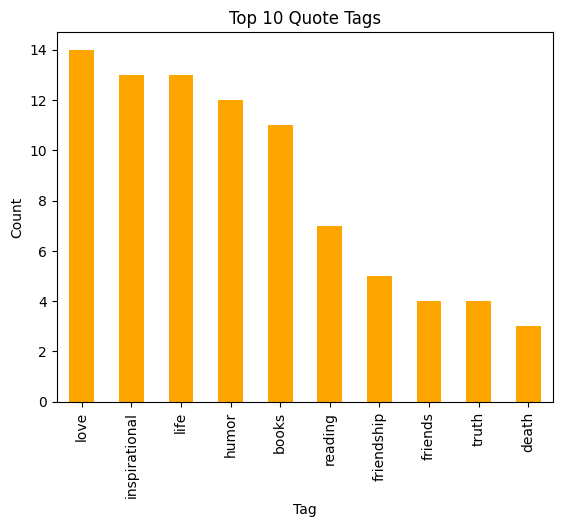

In [33]:
top_tags.head(10).plot(kind="bar", color="orange")
plt.title("Top 10 Quote Tags")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.show()